# Experimental CNN with Hexagonal Axial Pooling
Standalone notebook using a custom hexagonal sampling neighbourhood mapped onto the image grid.

1 1.1007719914118448
2 1.094510277112325
3 1.0942811833487616
4 1.0919868230819703
5 1.0898057222366333
6 1.0895045386420357
7 1.0814823071161905
8 1.0938338332706028
9 1.081629345152113
10 1.079454583591885
11 1.0669898337788053
12 1.0797136121326023
13 1.0675286889076232
14 1.0604343427552116
15 1.0665359934171041
16 1.0642294049263001
17 1.0605257365438674
18 1.045464689201779
19 1.045133908589681
20 1.0460018197695413
21 1.0473401188850402
22 1.043041918012831
23 1.0613345477316114
24 1.046263055006663
25 1.0396298342280919
26 1.0294884774419997
27 1.0397716522216798
28 1.0581474834018283
29 1.0394028504689534
30 1.0483242021666632
31 1.038223029507531
Weighted F1: 0.43950216933342684


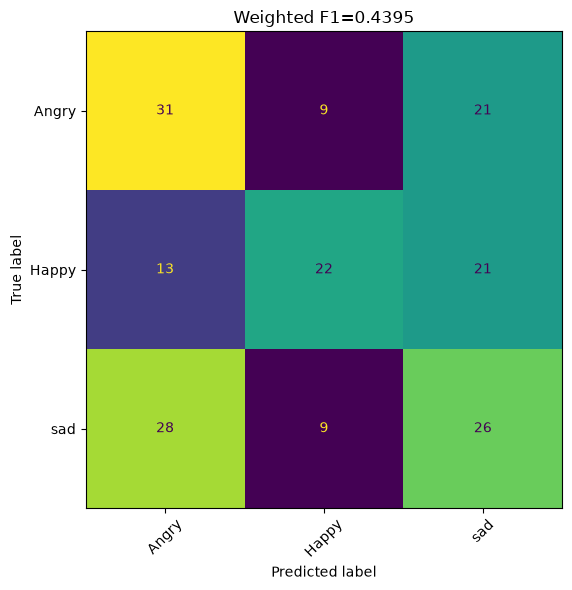

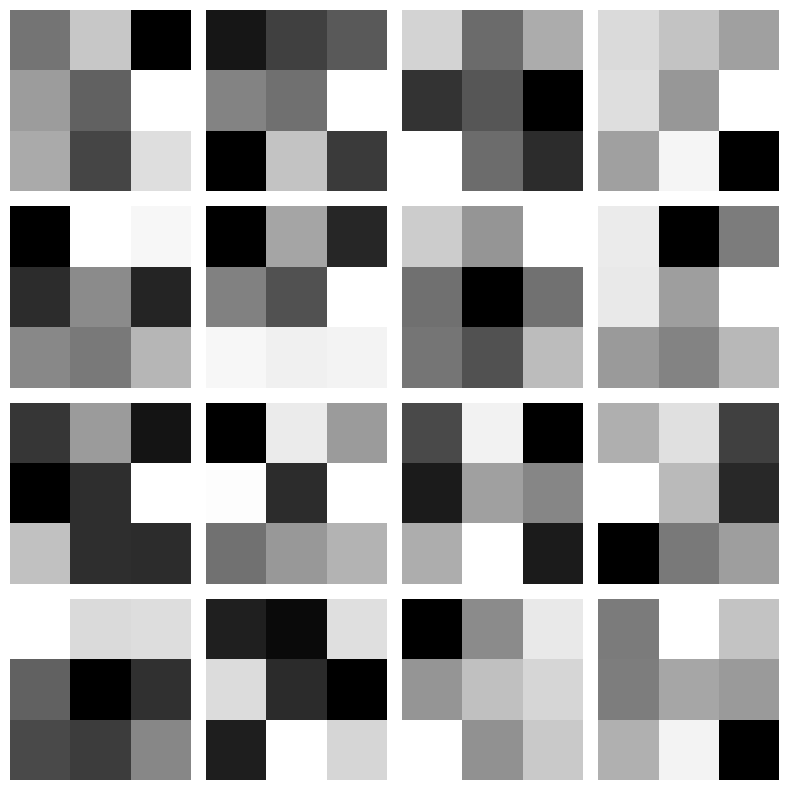

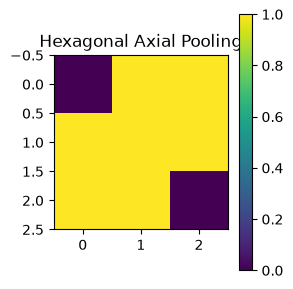

In [1]:

import os, zipfile, random
import numpy as np, pandas as pd
from PIL import Image
import cv2, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

MAX_EPOCHS=50
PATIENCE=5
BATCH_SIZE=16
IMG_SIZE=224
DEVICE="cuda" if torch.cuda.is_available() else "cpu"

if os.path.exists("archive.zip"):
    with zipfile.ZipFile("archive.zip","r") as z: z.extractall("dataset")

root="dataset"
while True:
    subs=[os.path.join(root,d) for d in os.listdir(root)] if os.path.isdir(root) else []
    dirs=[d for d in subs if os.path.isdir(d)]
    if len(dirs)==1 and not any(f.lower().endswith((".jpg",".jpeg",".png",".bmp")) for f in os.listdir(root)):
        root=dirs[0]
    else: break

class CLAHETransform:
    def __call__(self,img):
        a=np.array(img)
        lab=cv2.cvtColor(a,cv2.COLOR_RGB2LAB)
        l,A,B=cv2.split(lab)
        l=cv2.createCLAHE(2.0,(8,8)).apply(l)
        return Image.fromarray(cv2.cvtColor(cv2.merge((l,A,B)),cv2.COLOR_LAB2RGB))

train_tf=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),CLAHETransform(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.9,1.0)),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor()])
test_tf=transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),CLAHETransform(),transforms.ToTensor()])

base=datasets.ImageFolder(root)
idx=list(range(len(base))); random.shuffle(idx)
s=int(0.8*len(idx)); tr,te=idx[:s],idx[s:]

class Wrap(Dataset):
    def __init__(self,inds,tf): self.inds=inds; self.tf=tf
    def __len__(self): return len(self.inds)
    def __getitem__(self,i):
        p,l=base.samples[self.inds[i]]
        return self.tf(Image.open(p).convert("RGB")),l

train_loader=DataLoader(Wrap(tr,train_tf),batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(Wrap(te,test_tf),batch_size=BATCH_SIZE)

class HexAxialPool(nn.Module):
    """Hexagonal neighbourhood using axial-coordinate-inspired sampling on a square grid."""
    def __init__(self):
        super().__init__()
        # centre + six axial neighbours mapped into a 3x3 stencil
        k=torch.tensor([[0,1,1],
                        [1,1,1],
                        [1,1,0]],dtype=torch.float32)
        k/=k.sum()
        self.register_buffer("k",k)
    def forward(self,x):
        w=self.k.view(1,1,3,3).repeat(x.size(1),1,1,1)
        return torch.nn.functional.conv2d(x,w,stride=2,padding=1,groups=x.size(1))

class Net(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),nn.ReLU(),HexAxialPool(),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(),HexAxialPool(),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),HexAxialPool(),
            nn.AdaptiveAvgPool2d(1))
        self.fc=nn.Linear(64,n)
    def forward(self,x): return self.fc(self.features(x).flatten(1))

model=Net(len(base.classes)).to(DEVICE)
opt=torch.optim.Adam(model.parameters(),1e-3)
lossfn=nn.CrossEntropyLoss()
best=1e9; wait=0
for e in range(MAX_EPOCHS):
    model.train(); L=0
    for x,y in train_loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        opt.zero_grad(); out=model(x); loss=lossfn(out,y)
        loss.backward(); opt.step(); L+=loss.item()
    L/=max(1,len(train_loader)); print(e+1,L)
    if L<best:
        best=L; wait=0; torch.save(model.state_dict(),"best.pt")
    else:
        wait+=1
        if wait>=PATIENCE: break

model.load_state_dict(torch.load("best.pt",map_location=DEVICE))
model.eval(); pred=[]; true=[]
with torch.no_grad():
    for x,y in test_loader:
        pred.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy()); true.extend(y.numpy())
f1=f1_score(true,pred,average="weighted")
cm=confusion_matrix(true,pred)
fig,ax=plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(cm,display_labels=base.classes).plot(ax=ax,colorbar=False,xticks_rotation=45)
plt.title(f"Weighted F1={f1:.4f}")
plt.tight_layout(); plt.savefig("Alg2_results.jpg")
pd.DataFrame({"true":true,"pred":pred}).to_csv("Alg2_output.csv",index=False)

w=model.features[0].weight.detach().cpu()
fig=plt.figure(figsize=(8,8))
for i in range(min(16,w.shape[0])):
    ax=fig.add_subplot(4,4,i+1); ax.imshow(w[i].mean(0),cmap="gray"); ax.axis("off")
plt.tight_layout(); plt.savefig("Alg2_filter.jpg")

plt.figure(figsize=(3,3))
plt.imshow(np.array([[0,1,1],[1,1,1],[1,1,0]]),cmap="viridis")
plt.title("Hexagonal Axial Pooling")
plt.colorbar(); plt.tight_layout()
plt.savefig("Alg2_algorithm.jpg")
print("Weighted F1:",f1)
